In [2]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [3]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles;

Your version of python is not linked to helper_scripts.py
Congratulations- Your version of python is linked to the Atomic Simulation Environment


In [4]:
# Pyplot rcparams
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = false;
mlines = pyimport("matplotlib").lines
# General method to give red-green-blue values for plotting
rgb(x, y, z) = [x, y, z] ./ 255

rgb (generic function with 1 method)

In [5]:
# Phonon calculations indicate that only the buckled B substitution lattices are stable
bn22bc_dir="./BN22BC"
bn22bc_buckled_dir="./BN22BC_Buckled"
bn33bc_dir="./BN33BC"
bn33bc_buckled_dir="./BN33BC_Buckled"
bn44bc_dir="./BN44BC"
bn44bc_buckled_dir="./BN44BC_Buckled"
bn22nc_dir="./BN22NC"
bn33nc_dir="./BN33NC"
bn44nc_dir="./BN44NC"

bn3bc_dir="./BN3BC"
bn3nc_dir="./BN3NC"

Ag_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/3Dnew"
Argentene_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/2Dnew"
graphene_dir = "./Graphene";

# PBESOL, LDA, and PBE Comparison:

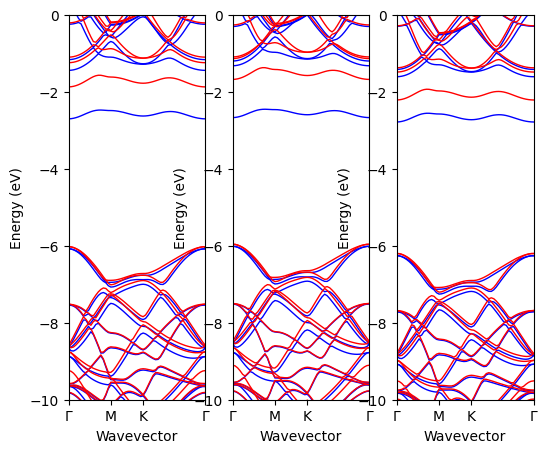

(-10.0, 0.0)

In [18]:
figure(figsize=(6, 5))
subplot(1, 3, 1)
plot_bands(bn33bc_dir*"/PBESOL/BN33BC.bands.eigenvals", spin=2, linewidth=1)
ylim(-10, 0)
subplot(1, 3, 2)
plot_bands(bn33bc_dir*"/BN33BC.bands.eigenvals", spin=2, linewidth=1)
ylim(-10, 0)
subplot(1, 3, 3)
plot_bands(bn33bc_dir*"/LDA/BN33BC.bands.eigenvals", spin=2, linewidth=1)
ylim(-10, 0)

In [9]:
μ22bc = -2.640839712362954
μ33bc = -2.5
μ44bc = -2.511
μ22nc = -4.713157401278416
μ33nc = -4.716750713951669
μ44nc = -4.624122722539408
μ3bc = -2.088258123632972
μ3nc = -5.665586558655866

-5.665586558655866

# Allbands.pdf (Main pdf for Figure 1)

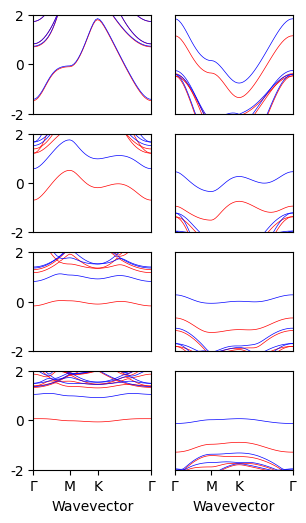

In [40]:
cm = 1/2.54
figure(figsize=(8.5cm, 15*cm))

color_up ="red"
color_dn = "blue"
num_cols = 2
num_rows = 4

subplot(num_rows, num_cols, 1)
plot_bands(bn3bc_dir*"/BN3BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5,)
ylim(μ3bc-2, μ3bc+2)
xlabel("")
ylabel("")
xticks([])
yticks([μ3bc-2, μ3bc, μ3bc+2], ["-2", "0", "2" ])

subplot(num_rows, num_cols, 2)
plot_bands(bn3nc_dir*"/BN3NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5,)
ylim(μ3nc-2, μ3nc+2)
xlabel("")
ylabel("")
xticks([])
yticks([])
#yticks([μ3nc-2, μ3nc, μ3nc+2], ["-2", "0", "2" ])

subplot(num_rows, num_cols, 3)
plot_bands(bn22bc_dir*"/BN22BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5,)
ylim(μ22bc-2, μ22bc+2)
yticks([μ22bc-2, μ22bc, μ22bc+2], ["-2", "0", "2" ])
xlabel("")
ylabel("")
xticks([])

subplot(num_rows, num_cols, 4)
plot_bands(bn22nc_dir*"/BN22NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5)
ylim(μ22nc-2, μ22nc+2)
xlabel("")
ylabel("")
yticks([])
xticks([])


subplot(num_rows, num_cols, 5)

plot_bands(bn33bc_dir*"/BN33BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5)
ylim(μ33bc-2, μ33bc+2)
yticks([μ33bc-2, μ33bc, μ33bc+2], ["-2", "0", "2" ])

xlabel("")
ylabel("")
xticks([])


subplot(num_rows, num_cols, 6)
plot_bands(bn33nc_dir*"/BN33NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5)
ylim(μ33nc-2, μ33nc+2)
xlabel("")
ylabel("")
yticks([])
xlabel("")
xticks([])


subplot(num_rows, num_cols, 7)
plot_bands(bn44bc_dir*"/BN44BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5)
ylim(μ44bc-2, μ44bc+2)
yticks([μ44bc-2, μ44bc, μ44bc+2], ["-2", "0", "2" ])

ylabel("")


subplot(num_rows, num_cols, 8)
plot_bands(bn44nc_dir*"/BN44NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5)
ylim(μ44nc-2, μ44nc+2)
ylabel("")
yticks([])


savefig("AllBands.pdf")

In [35]:
# Now we report the bandwidths

# BN3BC Bandwidth (3.3 eV)

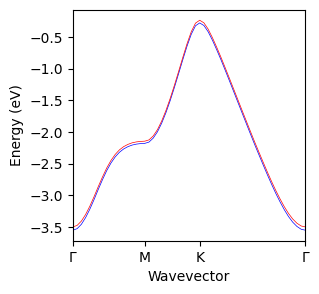

BN3NC bandwidth: 3.2773697965503814
Spin gap: 0.05186726439961875 


In [13]:
figure(figsize=(3, 3))
color_up = "blue"
color_dn = "red"
plot_bands(bn3bc_dir*"/BN3BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5,
whichbands=[13])
es_up, es_dn = JJDFTX.bandstruct_properties(bn3bc_dir*"/BN3BC.bands.eigenvals", kpointsfile=bn3bc_dir*"/bandstruct.kpoints",  spin =2);
println("BN3NC bandwidth: $(es_up[13][2] - es_up[13][1])")
println("Spin gap: $(es_dn[13][1] - es_up[13][1]) ")

# BN3NC Bandwidth (2.5 eV)

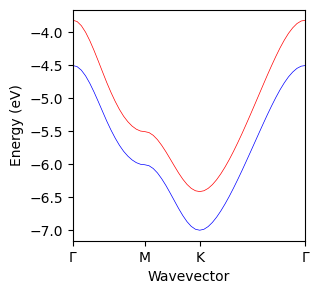

BN3NC bandwidth: 2.50024931800598
Spin gap: 0.5866136258396413 


In [6]:
figure(figsize=(3, 3))
color_up = "blue"
color_dn = "red"
plot_bands(bn3nc_dir*"/BN3NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5,
whichbands=[12])
es_up, es_dn = JJDFTX.bandstruct_properties(bn3nc_dir*"/BN3NC.bands.eigenvals", kpointsfile=bn3bc_dir*"/bandstruct.kpoints",  spin =2);
println("BN3NC bandwidth: $(es_up[12][2] - es_up[12][1])")
println("Spin gap: $(es_dn[12][1] - es_up[12][1]) ")

# BN22BC Bandwidth (1.21 eV)

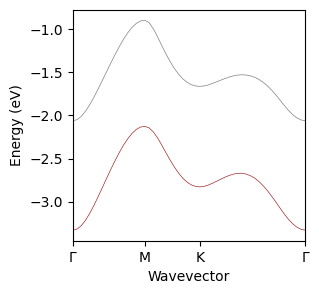

BN22BC bandwidth: 1.2063967746553539
Spin gap: 1.2713682382419984 


In [14]:
figure(figsize=(3, 3))
plot_bands(bn22bc_dir*"/BN22BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5,
whichbands=[17])
es_up, es_dn = JJDFTX.bandstruct_properties(bn22bc_dir*"/BN22BC.bands.eigenvals", kpointsfile=bn22bc_dir*"/bandstruct.kpoints",  spin =2);
println("BN22BC bandwidth: $(es_up[17][2] - es_up[17][1])")
println("Spin gap: $(es_dn[17][1] - es_up[17][1]) ")

# BN22NC Bandwidth (0.80 eV)

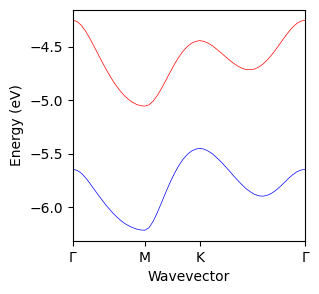

BN22NC bandwidth: 0.8017327954669966
Spin gap: 1.1582201130683885 
Distance from Valence Bands: 1.210073708866898 


In [10]:
figure(figsize=(3, 3))
plot_bands(bn22nc_dir*"/BN22NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5, 
whichbands=[16])
es_up, es_dn = JJDFTX.bandstruct_properties(bn22nc_dir*"/BN22NC.bands.eigenvals", kpointsfile=bn22nc_dir*"/bandstruct.kpoints",  spin =2);

println("BN22NC bandwidth: $(es_dn[16][2] - es_dn[16][1])")
println("Spin gap: $(es_dn[16][1] - es_up[16][1]) ")
println("Distance from Valence Bands: $(μ22nc - es_dn[15][2]) ")

# BN33BC Bandwidth (0.22 eV)

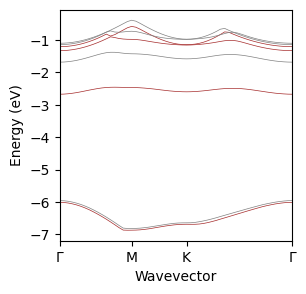

BN33BC bandwidth: 0.21723651486894502
Spin gap: 0.9916860801945471 


In [17]:
figure(figsize=(3, 3))
plot_bands(bn33bc_dir*"/BN33BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5,
whichbands=[36, 37, 38, 39])
es_up, es_dn = JJDFTX.bandstruct_properties(bn33bc_dir*"/BN33BC.bands.eigenvals", kpointsfile=bn33bc_dir*"/bandstruct.kpoints",  spin =2);
println("BN33BC bandwidth: $(es_up[37][2] - es_up[37][1])")
println("Spin gap: $(es_dn[37][1] - es_up[37][1]) ")

# BN33NC Bandwidth (0.34 eV)

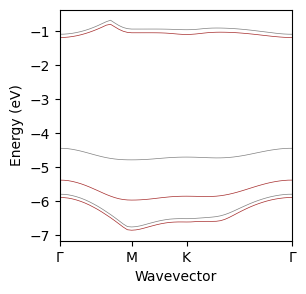

BN33NC bandwidth: 0.3405207981489884
Spin gap: 1.1810458479669688 


In [18]:
figure(figsize=(3, 3))
plot_bands(bn33nc_dir*"/BN33NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5, 
whichbands=[35, 36, 37])
es_up, es_dn = JJDFTX.bandstruct_properties(bn33nc_dir*"/BN33NC.bands.eigenvals", kpointsfile=bn33nc_dir*"/bandstruct.kpoints",  spin =2);

println("BN33NC bandwidth: $(es_dn[36][2]- es_dn[36][1])")
println("Spin gap: $(es_dn[36][1] - es_up[36][1]) ")

# BN44BC Bandwidth (0.13 eV)

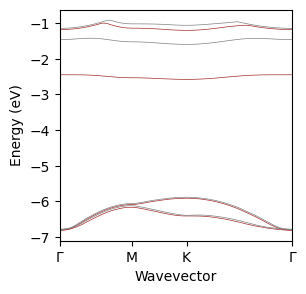

BN44BC bandwidth: 0.1295060107361392
Spin gap: 0.9822971038228117 


In [25]:
figure(figsize=(3, 3))
plot_bands(bn44bc_dir*"/BN44BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5,
whichbands=[63, 64, 65, 66])
es_up, es_dn = JJDFTX.bandstruct_properties(bn44bc_dir*"/BN44BC.bands.eigenvals", kpointsfile=bn44bc_dir*"/bandstruct.kpoints",  spin =2);
println("BN44BC bandwidth: $(es_up[65][2] - es_up[65][1])")
println("Spin gap: $(es_dn[65][1] - es_up[65][1]) ")

# BN44NC Bandwidth (0.19 eV)

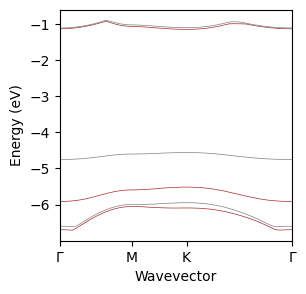

BN44NC bandwidth: 0.19342033695624483
Spin gap: 1.1600830017696655 


In [20]:
figure(figsize=(3, 3))
plot_bands(bn44nc_dir*"/BN44NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5, 
whichbands=[63, 64, 65])
es_up, es_dn = JJDFTX.bandstruct_properties(bn44nc_dir*"/BN44NC.bands.eigenvals", kpointsfile=bn44nc_dir*"/bandstruct.kpoints",  spin =2);

println("BN44NC bandwidth: $(es_dn[64][2]- es_dn[64][1])")
println("Spin gap: $(es_dn[64][1] - es_up[64][1]) ")